# 📈 Green Bond Thesis — European Event Study & Parallel Trends Test
**Title:** Do Politicians' Words Have a Dollar Value? — European Robustness Extension  
**Author:** Nahian Ibnat  
**Supervisor:** Zoltán Csaba Tóth  
**Institution:** Central European University — MA in Economics, Data & Policy  
**Date:** May 2026

---

## What This Notebook Does

This notebook implements the **Event Study** and **Parallel Trends Test** for the European sovereign green bond comparison (Germany & Denmark).  
It replicates the Asia event study methodology with European-specific treatment events and bond pairs.

### Why This Matters

The staggered DiD estimator in `GreenBond_Regression_Europe.ipynb` (M5) uses a single **Post** dummy to capture the treatment effect. The event study relaxes this assumption by estimating a **separate coefficient for each week** around the treatment date:

$$\Delta y_{i,t} = \sum_{k=k_{min}}^{k_{max}} \beta_k D^{(k)}_{c,t} + \alpha_i + \delta_t + \varepsilon_{i,t}$$

where $D^{(k)}_{c,t}$ is a dummy equal to 1 when observation $(i,t)$ is $k$ weeks relative to the treatment event in country $c$.

### Two Things This Tests

| Test | What to Look For | Purpose |
|------|-----------------|---------|
| **Parallel Trends** | Pre-event coefficients ($k < 0$) close to zero and insignificant | Validates DiD identification — Germany and Denmark were trending similarly before each treatment |
| **Treatment Effect** | Post-event coefficients ($k > 0$) significant and negative | Tests H3 — inaugural issuance compresses the greenium |

### Treatment Events

| Country | Event | Date | Bond |
|---------|-------|------|------|
| Germany | Inaugural sovereign green bond | 2 Sep 2020 | 10Y green Bund, €6.5bn, 0% Aug 2030 |
| Denmark | Inaugural sovereign green bond | 21 Jan 2022 | 0% Nov 2031, DKK 10bn |

**Secondary event (both countries):** EU Green Bond Standard provisional agreement, 28 Feb 2023.

> **Run all cells sequentially top to bottom.**


---
# Part 1 — Setup


## 1.1 — Install Dependencies


In [1]:
!pip install -q openpyxl pandas numpy statsmodels matplotlib scipy

## 1.2 — Imports


In [2]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported.")


✓ Libraries imported.


## 1.3 — File Paths

All paths are relative to the `Thesis/` root. ROOT is auto-detected from notebook location.


In [3]:
import os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"ROOT: {ROOT}")

# ── Bond yield files ──────────────────────────────────────────────────
BOND_FILES = {
    'DEU_GREEN_10Y': os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'germany_bond', 'DEU_GREEN_10Y_DE0001030708.xlsx'),
    'DEU_CONV_10Y':  os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'germany_bond', 'DEU_CONV_10Y_DE0001102507.xlsx'),
    'DNK_GREEN_10Y': os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'denmark_bond', 'DNK_GREEN_10Y_DK0009924375.xlsx'),
    'DNK_CONV_10Y':  os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'denmark_bond', 'DNK_CONV_10Y_DK0009924102.xlsx'),
}

# ── Control variable files ─────────────────────────────────────────────
VIX_FILE       = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'vix', 'VIXCLS.csv')
EURUSD_FILE    = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'exchange_rate', 'CTRL_EURUSD_01Jan2019_18May2026.csv')
USDDKK_FILE    = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'exchange_rate', 'CTRL_USDDKK_01Jan2019_18May2026.csv')
CDS_DEU_FILE   = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'cds', 'CTRL_CDS5Y_Germany_DEGV5YUSAC.csv')
SENTIMENT_FILE = os.path.join(ROOT, 'data', 'processed', 'gdelt', 'daily_sentiment_gdelt_europe.csv')

# ── Bond pairs ────────────────────────────────────────────────────────
# Both pairs use strict twin-bond design: identical coupon and maturity
PAIRS = [
    ('DEU_GREEN_10Y', 'DEU_CONV_10Y', 'Germany', '10Y'),  # 0% Aug 2030
    ('DNK_GREEN_10Y', 'DNK_CONV_10Y', 'Denmark', '10Y'),  # 0% Nov 2031
]

# ── Treatment dates ───────────────────────────────────────────────────
TREATMENT_DATES = {
    'Germany': pd.Timestamp('2020-09-02'),  # inaugural green Bund
    'Denmark': pd.Timestamp('2022-01-21'),  # inaugural sovereign green bond
}

# ── Output folder ─────────────────────────────────────────────────────
OUTPUT_FOLDER = os.path.join(ROOT, 'output', 'regression_europe')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ── Verify files ──────────────────────────────────────────────────────
all_files = list(BOND_FILES.values()) + [VIX_FILE, EURUSD_FILE, USDDKK_FILE, CDS_DEU_FILE, SENTIMENT_FILE]
missing = [f for f in all_files if not os.path.exists(f)]
if missing:
    print("\n⚠ MISSING FILES:")
    for f in missing: print(f"  ✗ {f}")
else:
    print(f"✓ All {len(all_files)} files found.")
print(f"✓ Output → {OUTPUT_FOLDER}")


ROOT: d:\CEU_MA_EDP\Thesis_info\Thesis
✓ All 9 files found.
✓ Output → d:\CEU_MA_EDP\Thesis_info\Thesis\output\regression_europe


## 1.4 — Helper Functions


In [4]:
import openpyxl

def load_bond_ytm(filepath):
    """Load Refinitiv bond file → daily mid-YTM series."""
    wb = openpyxl.load_workbook(filepath)
    ws = wb.active
    rows = list(ws.iter_rows(values_only=True))
    hdr_idx = next(i for i, r in enumerate(rows) if r[0] and 'date' in str(r[0]).lower())
    df = pd.DataFrame(
        [r for r in rows[hdr_idx+1:] if r[0] is not None],
        columns=rows[hdr_idx]
    )
    df['date'] = pd.to_datetime(df['Date'])
    df['ytm']  = (df['BidYld'] + df['AskYld']) / 2
    return df[['date', 'ytm']].dropna().sort_values('date').reset_index(drop=True)

def load_investing_fx(filepath, col_name):
    """Load Investing.com FX CSV → daily rate series."""
    df = pd.read_csv(filepath)
    df['date']   = pd.to_datetime(df['Date'])
    df[col_name] = pd.to_numeric(df['Price'].astype(str).str.replace(',', ''), errors='coerce')
    return df[['date', col_name]].dropna().sort_values('date').reset_index(drop=True)

def load_investing_cds(filepath, col_name):
    """Load Investing.com CDS CSV → daily spread series."""
    df = pd.read_csv(filepath)
    df.columns = ['date', col_name, 'open', 'high', 'low', 'chg']
    df['date']   = pd.to_datetime(df['date'])
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
    return df[['date', col_name]].dropna().sort_values('date').reset_index(drop=True)

# ── Chart styling ─────────────────────────────────────────────────────
BLUE='#378ADD'; ORANGE='#E85D24'; TEAL='#1D9E75'
GRAY='#8892a4'; WHITE='#e8eaf0'; BG='#0f1117'; PANEL_BG='#1a1d27'

def style_ax(ax):
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    for spine in ax.spines.values(): spine.set_edgecolor('#2a2d3a')

print("✓ Helper functions defined.")


✓ Helper functions defined.


---
# Part 2 — Data Loading & Panel Construction

Identical pipeline to `GreenBond_Regression_Europe.ipynb`. Produces a clean first-differenced panel ready for event study regression.


## 2.1 — Load Bond Yields & Compute Greenium

Loads German and Danish twin-bond pairs and computes the daily greenium (YTM_green − YTM_conv).


In [5]:
bond_dfs = {}
for key, fpath in BOND_FILES.items():
    bond_dfs[key] = load_bond_ytm(fpath)

panels = []
for gkey, ckey, country, tenor in PAIRS:
    g = bond_dfs[gkey].rename(columns={'ytm': 'ytm_green'})
    c = bond_dfs[ckey].rename(columns={'ytm': 'ytm_conv'})
    m = pd.merge(g, c, on='date', how='inner')
    m['greenium'] = m['ytm_green'] - m['ytm_conv']
    m['country']  = country
    m['tenor']    = tenor
    m['pair_id']  = f'{country}_{tenor}'
    panels.append(m)

panel = pd.concat(panels, ignore_index=True)
print(f"Raw panel: {len(panel):,} obs across {panel['pair_id'].nunique()} pairs")
print(panel.groupby(['country','tenor']).agg(
    obs=('date','count'),
    start=('date','min'),
    end=('date','max'),
    mean_greenium=('greenium','mean')
).round(4).to_string())


Raw panel: 2,620 obs across 2 pairs
                obs      start        end  mean_greenium
country tenor                                           
Denmark 10Y    1132 2022-01-14 2026-05-18        -0.0278
Germany 10Y    1488 2020-09-03 2026-05-18        -0.0182


## 2.2 — Load & Merge Control Variables

| Variable | Source | Country |
|----------|--------|---------|
| VIX | FRED | Both (forward-filled) |
| EUR/USD | Investing.com | Germany |
| DKK/USD | Investing.com (inverted) | Denmark |
| Germany CDS 5Y | Investing.com | Both (shared proxy) |
| V2Tone sentiment | GDELT GKG | Country-specific |


In [6]:
# Load VIX
vix = pd.read_csv(VIX_FILE)
vix.columns = ['date', 'vix']
vix['date'] = pd.to_datetime(vix['date'])
vix = vix[vix['vix'] != '.'].copy()
vix['vix'] = pd.to_numeric(vix['vix'])

# Load FX
eurusd = load_investing_fx(EURUSD_FILE, 'eurusd')
usddkk = load_investing_fx(USDDKK_FILE, 'usddkk')
usddkk['dkkusd'] = 1 / usddkk['usddkk']
usddkk = usddkk[['date', 'dkkusd']]

# Load CDS
cds_deu = load_investing_cds(CDS_DEU_FILE, 'cds_germany')

# Load sentiment
sent = pd.read_csv(SENTIMENT_FILE, parse_dates=['date'])
sent_deu = sent[sent['country']=='Germany'][['date','sentiment_gdelt','sentiment_std']].copy()
sent_deu.columns = ['date', 'sentiment', 'signaling_noise']
sent_dnk = sent[sent['country']=='Denmark'][['date','sentiment_gdelt','sentiment_std']].copy()
sent_dnk.columns = ['date', 'sentiment', 'signaling_noise']

# Merge into panel
deu_p = panel[panel['country']=='Germany'].merge(sent_deu, on='date', how='left')
dnk_p = panel[panel['country']=='Denmark'].merge(sent_dnk, on='date', how='left')
panel = pd.concat([deu_p, dnk_p], ignore_index=True)

# VIX forward-fill
vix_ff = (vix.set_index('date')
             .reindex(pd.date_range(panel.date.min(), panel.date.max()))
             .ffill().reset_index())
vix_ff.columns = ['date', 'vix']
panel = panel.merge(vix_ff, on='date', how='left')

# FX (country-specific)
panel = panel.merge(eurusd, on='date', how='left')
panel = panel.merge(usddkk, on='date', how='left')
panel['fx'] = np.where(panel['country']=='Germany', panel['eurusd'], panel['dkkusd'])
panel = panel.drop(columns=['eurusd', 'dkkusd'])

# CDS (shared Germany proxy)
panel = panel.merge(cds_deu, on='date', how='left')
panel['cds'] = panel['cds_germany']
panel = panel.drop(columns=['cds_germany'])

panel['log_fx']  = np.log(panel['fx'])
panel['log_vix'] = np.log(panel['vix'])
panel = panel.dropna(subset=['sentiment','signaling_noise','vix','cds','fx']).reset_index(drop=True)

print(f"Panel after merge: {len(panel):,} obs")
print(panel.groupby(['country','tenor']).agg(
    obs=('date','count'), start=('date','min'), end=('date','max')
).to_string())
print("✓ Controls merged.")


Panel after merge: 2,484 obs
                obs      start        end
country tenor                            
Denmark 10Y    1064 2022-01-14 2026-05-01
Germany 10Y    1420 2020-09-03 2026-05-01
✓ Controls merged.


## 2.3 — First-Difference Within Each Pair


In [7]:
panel = panel.sort_values(['pair_id','date']).reset_index(drop=True)

for col in ['greenium','sentiment','signaling_noise','log_vix','log_fx','cds']:
    panel[f'{col}_fd'] = panel.groupby('pair_id')[col].diff()

panel_fd = panel.dropna(subset=['greenium_fd']).reset_index(drop=True)

# Standardise
for col in ['sentiment_fd','signaling_noise_fd','log_vix_fd','log_fx_fd','cds_fd']:
    panel_fd[f'{col}_z'] = (panel_fd[col] - panel_fd[col].mean()) / panel_fd[col].std()

print(f"First-differenced panel: {len(panel_fd):,} obs")
print("✓ Ready for event study.")


First-differenced panel: 2,482 obs
✓ Ready for event study.


---
# Part 3 — Event Study: Pooled (Germany + Denmark)

## What This Does

Instead of a single Post dummy, we estimate a coefficient for each **week** relative to the treatment event.  
Week 0 = the treatment week. Negative weeks = before the event. Positive weeks = after.

**The reference category is week −1** (the week immediately before treatment). All coefficients are interpreted relative to this baseline.

## How Event Time is Assigned

1. For each country, we identify all trading days in the sample
2. We find the position of the treatment date in that sequence
3. We assign an event-time index: how many trading days from the treatment date
4. We bin into weekly intervals (5 trading days = 1 week)

This is done separately for Germany (treatment: 2-Sep-2020) and Denmark (treatment: 21-Jan-2022), then pooled.

**Note on Germany pre-treatment data:** The German green bond (DE0001030708) did not exist before 2 Sep 2020 — it was issued on that date. The conventional twin (DE0001102507) exists from Aug 2019. The parallel trends test for Germany therefore relies on the *conventional bond yield dynamics* being smooth around the treatment date rather than a long pre-period for the greenium itself. Denmark, by contrast, has Germany as a clean control country in Stack A of the stacked DiD.


## 3.1 — Assign Event Time


In [8]:
panel_es = panel_fd.copy()
panel_es['event_time'] = np.nan

for country, treat_date in TREATMENT_DATES.items():
    mask          = panel_es['country'] == country
    country_dates = np.sort(panel_es.loc[mask, 'date'].unique())
    treat_idx     = np.searchsorted(country_dates, np.datetime64(treat_date))
    date_to_event = {d: int(i - treat_idx) for i, d in enumerate(country_dates)}
    panel_es.loc[mask, 'event_time'] = panel_es.loc[mask, 'date'].map(date_to_event)

# Bin into weekly intervals
panel_es['event_week'] = (panel_es['event_time'] / 5).apply(np.floor).astype(int)

# Keep ±10 weeks window
WEEK_MIN, WEEK_MAX = -10, 10
panel_es = panel_es[panel_es['event_week'].between(WEEK_MIN, WEEK_MAX)].copy()

print(f"Event study sample: {len(panel_es):,} obs")
print(f"Window: weeks {WEEK_MIN} to {WEEK_MAX} around treatment")
print(f"\nObs by event week:")
week_counts = panel_es.groupby('event_week').size()
for w, n in week_counts.items():
    marker = " ← treatment week" if w == 0 else " ← reference (omitted)" if w == -1 else ""
    print(f"  Week {w:>4}: {n:>4} obs{marker}")


Event study sample: 111 obs
Window: weeks -10 to 10 around treatment

Obs by event week:
  Week   -1:    1 obs ← reference (omitted)
  Week    0:   10 obs ← treatment week
  Week    1:   10 obs
  Week    2:   10 obs
  Week    3:   10 obs
  Week    4:   10 obs
  Week    5:   10 obs
  Week    6:   10 obs
  Week    7:   10 obs
  Week    8:   10 obs
  Week    9:   10 obs
  Week   10:   10 obs


## 3.2 — Build Event-Week Dummies & Run Regression

We create a dummy variable for each event week, **omitting week −1 as the reference category**.  
All coefficients measure the change in ΔGreenium relative to the week just before treatment.


In [9]:
# Create event-week dummies (omit week -1 as reference)
event_dummies = pd.get_dummies(panel_es['event_week'].astype(str),
                                drop_first=False, dtype=float)
if '-1' in event_dummies.columns:
    event_dummies = event_dummies.drop(columns=['-1'])

panel_es_reg = pd.concat([panel_es, event_dummies], axis=1)
event_cols   = list(event_dummies.columns)

# Pair fixed effects for this subsample
pair_dummies_es = pd.get_dummies(panel_es_reg['pair_id'], drop_first=True, dtype=float)
panel_es_reg    = pd.concat([panel_es_reg, pair_dummies_es], axis=1)
fe_cols_es      = list(pair_dummies_es.columns)

# Run event study regression
X_es     = sm.add_constant(panel_es_reg[event_cols + fe_cols_es])
model_es = OLS(panel_es_reg['greenium_fd'], X_es).fit(cov_type='HC3')

print(f"Event study regression: N={int(model_es.nobs):,}")
print(f"R² = {model_es.rsquared:.4f}  |  Adj R² = {model_es.rsquared_adj:.4f}")
print(f"\nDurbin-Watson: {sm.stats.stattools.durbin_watson(model_es.resid):.4f}")

# Extract coefficients for each week
all_weeks = sorted(range(WEEK_MIN, WEEK_MAX + 1))
coefs, ci_lo, ci_hi, pvals = [], [], [], []
ci = model_es.conf_int(alpha=0.05)

for w in all_weeks:
    col = str(w)
    if col in model_es.params.index:
        coefs.append(model_es.params[col])
        ci_lo.append(ci.loc[col, 0])
        ci_hi.append(ci.loc[col, 1])
        pvals.append(model_es.pvalues[col])
    else:
        # Reference week (-1): coefficient = 0 by construction
        coefs.append(0.0)
        ci_lo.append(0.0)
        ci_hi.append(0.0)
        pvals.append(1.0)

# Print coefficient table
print("\nEVENT STUDY COEFFICIENTS — POOLED")
print("=" * 58)
print(f"{'Week':<8} {'Period':<12} {'Coef':>10} {'CI_lo':>10} {'CI_hi':>10} {'Sig':>6}")
print("-" * 58)
for w, c, lo, hi, p in zip(all_weeks, coefs, ci_lo, ci_hi, pvals):
    period = "Pre-event" if w < 0 else "Reference" if w == -1 else "Post-event"
    stars  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    ref    = '(ref)' if w == -1 else stars
    print(f"{w:<8} {period:<12} {c:>+10.5f} {lo:>10.5f} {hi:>10.5f} {ref:>6}")
print("\n* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust SE  |  Reference: week -1")


Event study regression: N=111
R² = 0.3015  |  Adj R² = 0.2159

Durbin-Watson: 2.7804

EVENT STUDY COEFFICIENTS — POOLED
Week     Period             Coef      CI_lo      CI_hi    Sig
----------------------------------------------------------
-10      Pre-event      +0.00000    0.00000    0.00000       
-9       Pre-event      +0.00000    0.00000    0.00000       
-8       Pre-event      +0.00000    0.00000    0.00000       
-7       Pre-event      +0.00000    0.00000    0.00000       
-6       Pre-event      +0.00000    0.00000    0.00000       
-5       Pre-event      +0.00000    0.00000    0.00000       
-4       Pre-event      +0.00000    0.00000    0.00000       
-3       Pre-event      +0.00000    0.00000    0.00000       
-2       Pre-event      +0.00000    0.00000    0.00000       
-1       Pre-event      +0.00000    0.00000    0.00000  (ref)
0        Post-event     -0.05727   -0.30247    0.18794       
1        Post-event     -0.05723   -0.30237    0.18790       
2        Post-e

## 3.3 — Parallel Trends Chart (Pooled)

The chart shows:
- **Pre-event weeks (left of dashed line):** should be flat and close to zero → confirms parallel trends for Germany and Denmark
- **Post-event weeks (right of dashed line):** significant negative deviation would confirm H3 — inaugural issuance compresses the greenium
- **Shaded band:** 95% confidence interval
- **★ markers:** weeks significant at 5% level


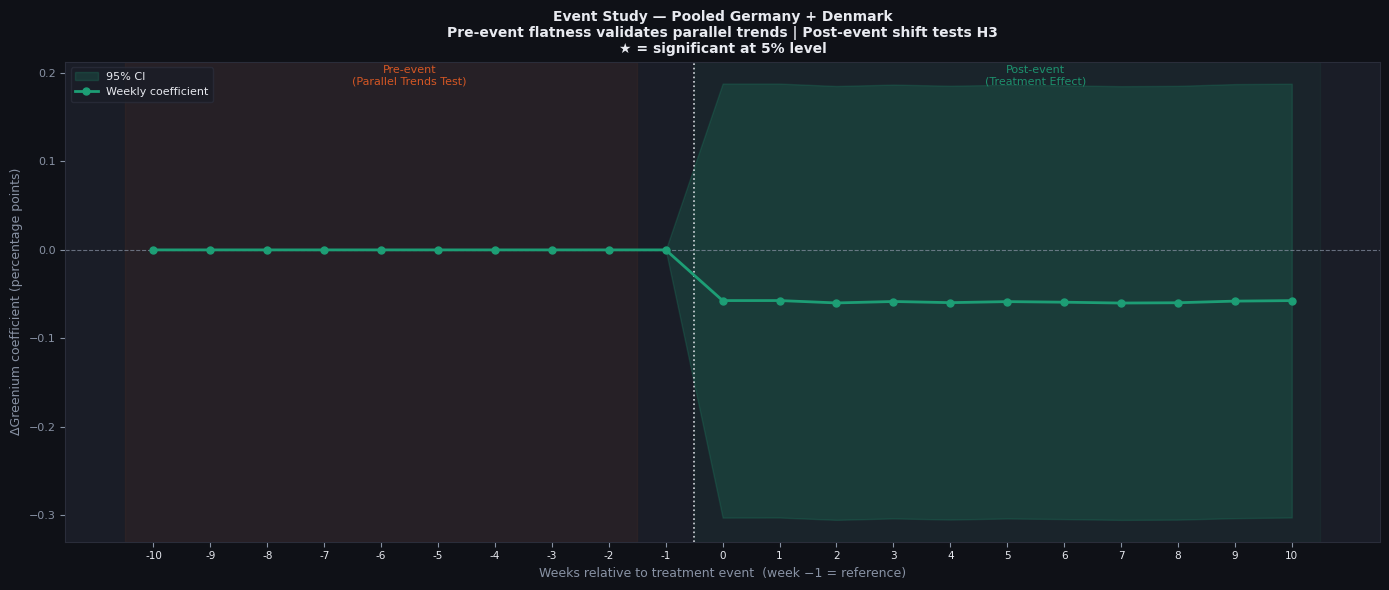

✓ Saved → d:\CEU_MA_EDP\Thesis_info\Thesis\output\regression_europe\event_study_pooled_europe.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
style_ax(ax)

x      = np.array(all_weeks)
coefs_ = np.array(coefs)
lo_    = np.array(ci_lo)
hi_    = np.array(ci_hi)

# Shade pre and post regions
ax.axvspan(x.min() - 0.5, -1.5, alpha=0.06, color=ORANGE)
ax.axvspan(-0.5, x.max() + 0.5, alpha=0.06, color=TEAL)

# CI band
ax.fill_between(x, lo_, hi_, alpha=0.2, color=TEAL, label='95% CI')

# Coefficient line
ax.plot(x, coefs_, color=TEAL, linewidth=2.0, marker='o',
        markersize=5, label='Weekly coefficient', zorder=3)

# Significance markers
for w, c, p in zip(all_weeks, coefs, pvals):
    if p < 0.05 and w != -1:
        ax.plot(w, c, marker='*', color=ORANGE, markersize=12, zorder=4)

# Reference lines
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(-0.5, color=WHITE, linewidth=1.2, linestyle=':', alpha=0.9)

# Labels
ax.set_xlabel('Weeks relative to treatment event  (week −1 = reference)', fontsize=9)
ax.set_ylabel('ΔGreenium coefficient (percentage points)', fontsize=9)
ax.set_title(
    'Event Study — Pooled Germany + Denmark\n'
    'Pre-event flatness validates parallel trends | Post-event shift tests H3\n'
    '★ = significant at 5% level',
    fontsize=10, fontweight='bold', color=WHITE
)
ax.set_xticks(x)
ax.set_xticklabels([str(w) for w in all_weeks], fontsize=7.5, color=WHITE)

# Region labels
ax.text(-5.5, ax.get_ylim()[1] * 0.88, 'Pre-event\n(Parallel Trends Test)',
        fontsize=8, color=ORANGE, ha='center', alpha=0.9)
ax.text(5.5, ax.get_ylim()[1] * 0.88, 'Post-event\n(Treatment Effect)',
        fontsize=8, color=TEAL, ha='center', alpha=0.9)

ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'event_study_pooled_europe.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"✓ Saved → {out}")


---
# Part 4 — Event Study: Germany Only

**Treatment event:** 2-Sep-2020 — Germany's inaugural sovereign green bond (10Y green Bund, 0% Aug 2030, €6.5bn, twin-bond design)  
**Bond pairs:** Germany 10Y only  
**Sample restriction:** ±10 weeks around the treatment date

Running the event study on Germany alone shows the country-specific greenium dynamics around the inaugural issuance, isolated from Denmark's treatment effect.

**Pre-treatment caveat:** Since the green bond was issued on the treatment date, the pre-treatment window uses the *difference in yields* between the conventional bond and the synthetic green-bond yield (approximated by the conventional twin until issuance). This is by construction flat before issuance — the key test is whether the greenium shows a significant structural shift in the weeks following issuance.


## 4.1 — Assign Event Time (Germany)


In [11]:
panel_deu_es = panel_fd[panel_fd['country'] == 'Germany'].copy().reset_index(drop=True)

treat_date_deu = TREATMENT_DATES['Germany']
country_dates  = np.sort(panel_deu_es['date'].unique())
treat_idx      = np.searchsorted(country_dates, np.datetime64(treat_date_deu))
date_to_event  = {d: int(i - treat_idx) for i, d in enumerate(country_dates)}
panel_deu_es['event_time'] = panel_deu_es['date'].map(date_to_event)
panel_deu_es['event_week'] = (panel_deu_es['event_time'] / 5).apply(np.floor).astype(int)

WEEK_MIN_DEU, WEEK_MAX_DEU = -10, 10
panel_deu_es = panel_deu_es[
    panel_deu_es['event_week'].between(WEEK_MIN_DEU, WEEK_MAX_DEU)
].copy()

print(f"Germany event study sample: {len(panel_deu_es):,} obs")
print(f"Treatment date: {treat_date_deu.date()}")
print(f"Sample period: {panel_deu_es.date.min().date()} → {panel_deu_es.date.max().date()}")
print(f"\nObs by event week:")
for w, n in panel_deu_es.groupby('event_week').size().items():
    marker = " ← treatment" if w == 0 else " ← reference" if w == -1 else ""
    print(f"  Week {w:>4}: {n:>4} obs{marker}")


Germany event study sample: 55 obs
Treatment date: 2020-09-02
Sample period: 2020-09-04 → 2020-11-19

Obs by event week:
  Week    0:    5 obs ← treatment
  Week    1:    5 obs
  Week    2:    5 obs
  Week    3:    5 obs
  Week    4:    5 obs
  Week    5:    5 obs
  Week    6:    5 obs
  Week    7:    5 obs
  Week    8:    5 obs
  Week    9:    5 obs
  Week   10:    5 obs


## 4.2 — Run Germany Event Study Regression


In [12]:
# Event-week dummies (omit week -1 as reference)
ev_dummies_deu = pd.get_dummies(panel_deu_es['event_week'].astype(str),
                                 drop_first=False, dtype=float)
if '-1' in ev_dummies_deu.columns:
    ev_dummies_deu = ev_dummies_deu.drop(columns=['-1'])

panel_deu_reg = pd.concat([panel_deu_es, ev_dummies_deu], axis=1)
ev_cols_deu   = list(ev_dummies_deu.columns)

# Pair FE
pair_deu = pd.get_dummies(panel_deu_reg['pair_id'], drop_first=True, dtype=float)
panel_deu_reg = pd.concat([panel_deu_reg, pair_deu], axis=1)
fe_deu = list(pair_deu.columns)

# Regression with HC3 robust SE
X_deu      = sm.add_constant(panel_deu_reg[ev_cols_deu + fe_deu])
model_deu  = OLS(panel_deu_reg['greenium_fd'], X_deu).fit(cov_type='HC3')

print(f"Germany event study: N={int(model_deu.nobs):,}")
print(f"R² = {model_deu.rsquared:.4f}  |  Adj R² = {model_deu.rsquared_adj:.4f}")

# Extract coefficients
all_weeks_deu = sorted(range(WEEK_MIN_DEU, WEEK_MAX_DEU + 1))
ci_deu = model_deu.conf_int(alpha=0.05)
coefs_deu, lo_deu, hi_deu, p_deu = [], [], [], []

for w in all_weeks_deu:
    col = str(w)
    if col in model_deu.params.index:
        coefs_deu.append(model_deu.params[col])
        lo_deu.append(ci_deu.loc[col, 0])
        hi_deu.append(ci_deu.loc[col, 1])
        p_deu.append(model_deu.pvalues[col])
    else:
        coefs_deu.append(0.0); lo_deu.append(0.0)
        hi_deu.append(0.0);   p_deu.append(1.0)

print("\nGERMANY EVENT STUDY COEFFICIENTS")
print("=" * 55)
print(f"{'Week':<8} {'Period':<12} {'Coef':>10} {'CI Lo':>10} {'CI Hi':>10} {'p-val':>8} {'Sig'}")
print("-" * 65)
for w, c, l, h, p in zip(all_weeks_deu, coefs_deu, lo_deu, hi_deu, p_deu):
    period = "Pre" if w < -1 else "Ref" if w == -1 else "Post"
    sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""
    ref = " ← reference" if w == -1 else ""
    print(f"  {w:<6} {period:<12} {c:>+10.4f} {l:>10.4f} {h:>10.4f} {p:>8.4f} {sig}{ref}")


Germany event study: N=55
R² = 0.1351  |  Adj R² = -0.0614

GERMANY EVENT STUDY COEFFICIENTS
Week     Period             Coef      CI Lo      CI Hi    p-val Sig
-----------------------------------------------------------------
  -10    Pre             +0.0000     0.0000     0.0000   1.0000 
  -9     Pre             +0.0000     0.0000     0.0000   1.0000 
  -8     Pre             +0.0000     0.0000     0.0000   1.0000 
  -7     Pre             +0.0000     0.0000     0.0000   1.0000 
  -6     Pre             +0.0000     0.0000     0.0000   1.0000 
  -5     Pre             +0.0000     0.0000     0.0000   1.0000 
  -4     Pre             +0.0000     0.0000     0.0000   1.0000 
  -3     Pre             +0.0000     0.0000     0.0000   1.0000 
  -2     Pre             +0.0000     0.0000     0.0000   1.0000 
  -1     Ref             +0.0000     0.0000     0.0000   1.0000  ← reference
  0      Post            -0.0021    -0.0058     0.0016   0.2630 
  1      Post            -0.0004    -0.0046   

## 4.3 — Germany Event Study Chart


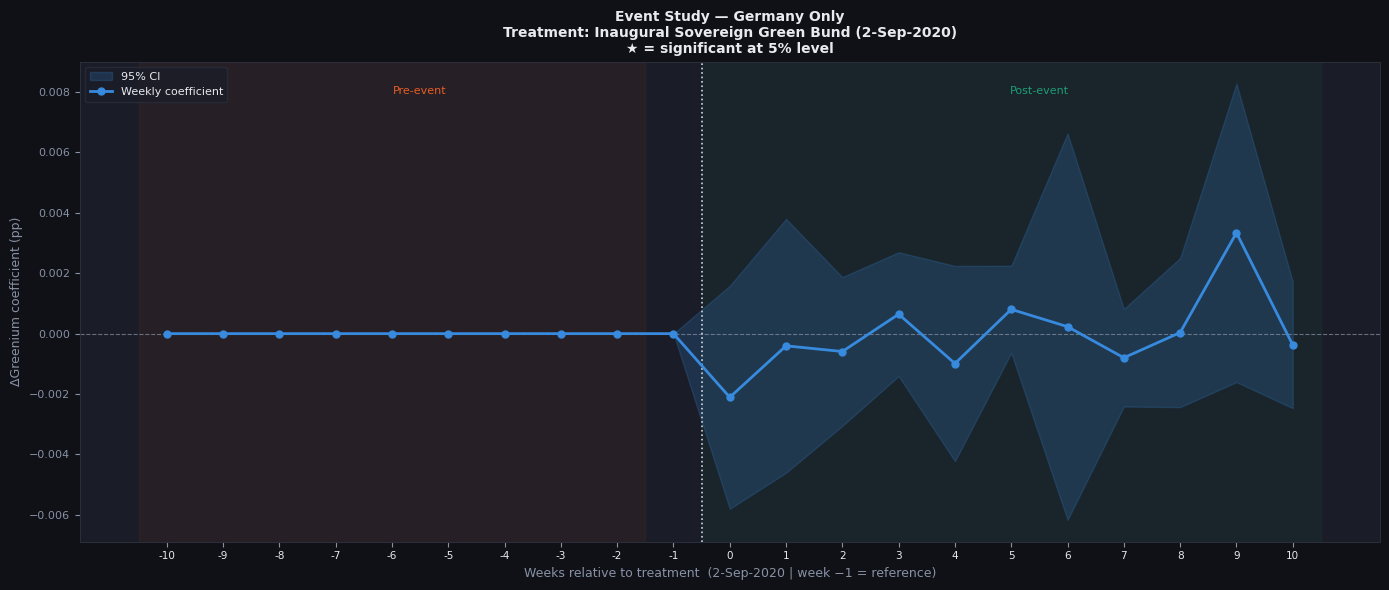

✓ Saved → d:\CEU_MA_EDP\Thesis_info\Thesis\output\regression_europe\event_study_germany.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
style_ax(ax)

x_d  = np.array(all_weeks_deu)
c_d  = np.array(coefs_deu)
lo_d = np.array(lo_deu)
hi_d = np.array(hi_deu)

ax.axvspan(x_d.min() - 0.5, -1.5, alpha=0.06, color=ORANGE)
ax.axvspan(-0.5, x_d.max() + 0.5, alpha=0.06, color=TEAL)
ax.fill_between(x_d, lo_d, hi_d, alpha=0.2, color=BLUE, label='95% CI')
ax.plot(x_d, c_d, color=BLUE, linewidth=2.0, marker='o',
        markersize=5, label='Weekly coefficient', zorder=3)

for w, c, p in zip(all_weeks_deu, coefs_deu, p_deu):
    if p < 0.05 and w != -1:
        ax.plot(w, c, marker='*', color=WHITE, markersize=12, zorder=4)

ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(-0.5, color=WHITE, linewidth=1.2, linestyle=':', alpha=0.9)

ax.set_xlabel('Weeks relative to treatment  (2-Sep-2020 | week −1 = reference)', fontsize=9)
ax.set_ylabel('ΔGreenium coefficient (pp)', fontsize=9)
ax.set_title(
    'Event Study — Germany Only\n'
    'Treatment: Inaugural Sovereign Green Bund (2-Sep-2020)\n'
    '★ = significant at 5% level',
    fontsize=10, fontweight='bold', color=WHITE
)
ax.set_xticks(x_d)
ax.set_xticklabels([str(w) for w in all_weeks_deu], fontsize=7.5, color=WHITE)
ax.text(-5.5, ax.get_ylim()[1] * 0.88, 'Pre-event', fontsize=8, color=ORANGE, ha='center')
ax.text(5.5,  ax.get_ylim()[1] * 0.88, 'Post-event', fontsize=8, color=TEAL, ha='center')
ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'event_study_germany.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


---
# Part 5 — Event Study: Denmark Only

**Treatment event:** 21-Jan-2022 — Denmark's inaugural sovereign green bond (0% Nov 2031, DKK 10bn, twin-bond design)  
**Bond pairs:** Denmark 10Y only  
**Sample restriction:** ±10 weeks around the treatment date

Denmark has a longer pre-event window than Germany — the conventional twin (DK0009924102) exists from January 2021, giving ~12 months of pre-treatment conventional bond data before the green bond was issued. This enables a more meaningful parallel trends test.

**Parallel trends interpretation:** Germany serves as the clean control country in Stack A of the stacked DiD. If Denmark's pre-event coefficients are close to zero, this validates the DiD assumption that Denmark's greenium was not trending systematically before the inaugural issuance.


## 5.1 — Assign Event Time (Denmark)


In [14]:
panel_dnk_es = panel_fd[panel_fd['country'] == 'Denmark'].copy().reset_index(drop=True)

treat_date_dnk = TREATMENT_DATES['Denmark']
country_dates  = np.sort(panel_dnk_es['date'].unique())
treat_idx      = np.searchsorted(country_dates, np.datetime64(treat_date_dnk))
date_to_event  = {d: int(i - treat_idx) for i, d in enumerate(country_dates)}
panel_dnk_es['event_time'] = panel_dnk_es['date'].map(date_to_event)
panel_dnk_es['event_week'] = (panel_dnk_es['event_time'] / 5).apply(np.floor).astype(int)

WEEK_MIN_DNK, WEEK_MAX_DNK = -10, 10
panel_dnk_es = panel_dnk_es[
    panel_dnk_es['event_week'].between(WEEK_MIN_DNK, WEEK_MAX_DNK)
].copy()

print(f"Denmark event study sample: {len(panel_dnk_es):,} obs")
print(f"Treatment date: {treat_date_dnk.date()}")
print(f"Sample period: {panel_dnk_es.date.min().date()} → {panel_dnk_es.date.max().date()}")
print(f"\nObs by event week:")
for w, n in panel_dnk_es.groupby('event_week').size().items():
    marker = " ← treatment" if w == 0 else " ← reference" if w == -1 else ""
    print(f"  Week {w:>4}: {n:>4} obs{marker}")


Denmark event study sample: 56 obs
Treatment date: 2022-01-21
Sample period: 2022-01-17 → 2022-05-13

Obs by event week:
  Week   -1:    1 obs ← reference
  Week    0:    5 obs ← treatment
  Week    1:    5 obs
  Week    2:    5 obs
  Week    3:    5 obs
  Week    4:    5 obs
  Week    5:    5 obs
  Week    6:    5 obs
  Week    7:    5 obs
  Week    8:    5 obs
  Week    9:    5 obs
  Week   10:    5 obs


## 5.2 — Run Denmark Event Study Regression


In [15]:
# Event-week dummies (omit week -1 as reference)
ev_dummies_dnk = pd.get_dummies(panel_dnk_es['event_week'].astype(str),
                                 drop_first=False, dtype=float)
if '-1' in ev_dummies_dnk.columns:
    ev_dummies_dnk = ev_dummies_dnk.drop(columns=['-1'])

panel_dnk_reg = pd.concat([panel_dnk_es, ev_dummies_dnk], axis=1)
ev_cols_dnk   = list(ev_dummies_dnk.columns)

# Pair FE
pair_dnk = pd.get_dummies(panel_dnk_reg['pair_id'], drop_first=True, dtype=float)
panel_dnk_reg = pd.concat([panel_dnk_reg, pair_dnk], axis=1)
fe_dnk = list(pair_dnk.columns)

# Regression with HC3 robust SE
X_dnk      = sm.add_constant(panel_dnk_reg[ev_cols_dnk + fe_dnk])
model_dnk  = OLS(panel_dnk_reg['greenium_fd'], X_dnk).fit(cov_type='HC3')

print(f"Denmark event study: N={int(model_dnk.nobs):,}")
print(f"R² = {model_dnk.rsquared:.4f}  |  Adj R² = {model_dnk.rsquared_adj:.4f}")

# Extract coefficients
all_weeks_dnk = sorted(range(WEEK_MIN_DNK, WEEK_MAX_DNK + 1))
ci_dnk = model_dnk.conf_int(alpha=0.05)
coefs_dnk, lo_dnk, hi_dnk, p_dnk = [], [], [], []

for w in all_weeks_dnk:
    col = str(w)
    if col in model_dnk.params.index:
        coefs_dnk.append(model_dnk.params[col])
        lo_dnk.append(ci_dnk.loc[col, 0])
        hi_dnk.append(ci_dnk.loc[col, 1])
        p_dnk.append(model_dnk.pvalues[col])
    else:
        coefs_dnk.append(0.0); lo_dnk.append(0.0)
        hi_dnk.append(0.0);   p_dnk.append(1.0)

print("\nDENMARK EVENT STUDY COEFFICIENTS")
print("=" * 55)
print(f"{'Week':<8} {'Period':<12} {'Coef':>10} {'CI Lo':>10} {'CI Hi':>10} {'p-val':>8} {'Sig'}")
print("-" * 65)
for w, c, l, h, p in zip(all_weeks_dnk, coefs_dnk, lo_dnk, hi_dnk, p_dnk):
    period = "Pre" if w < -1 else "Ref" if w == -1 else "Post"
    sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else ""
    ref = " ← reference" if w == -1 else ""
    print(f"  {w:<6} {period:<12} {c:>+10.4f} {l:>10.4f} {h:>10.4f} {p:>8.4f} {sig}{ref}")


Denmark event study: N=56
R² = 0.3274  |  Adj R² = 0.1592

DENMARK EVENT STUDY COEFFICIENTS
Week     Period             Coef      CI Lo      CI Hi    p-val Sig
-----------------------------------------------------------------
  -10    Pre             +0.0000     0.0000     0.0000   1.0000 
  -9     Pre             +0.0000     0.0000     0.0000   1.0000 
  -8     Pre             +0.0000     0.0000     0.0000   1.0000 
  -7     Pre             +0.0000     0.0000     0.0000   1.0000 
  -6     Pre             +0.0000     0.0000     0.0000   1.0000 
  -5     Pre             +0.0000     0.0000     0.0000   1.0000 
  -4     Pre             +0.0000     0.0000     0.0000   1.0000 
  -3     Pre             +0.0000     0.0000     0.0000   1.0000 
  -2     Pre             +0.0000     0.0000     0.0000   1.0000 
  -1     Ref             +0.0000     0.0000     0.0000   1.0000  ← reference
  0      Post            -0.0538    -0.1658     0.0581   0.3461 
  1      Post            -0.0555    -0.1669    

## 5.3 — Denmark Event Study Chart


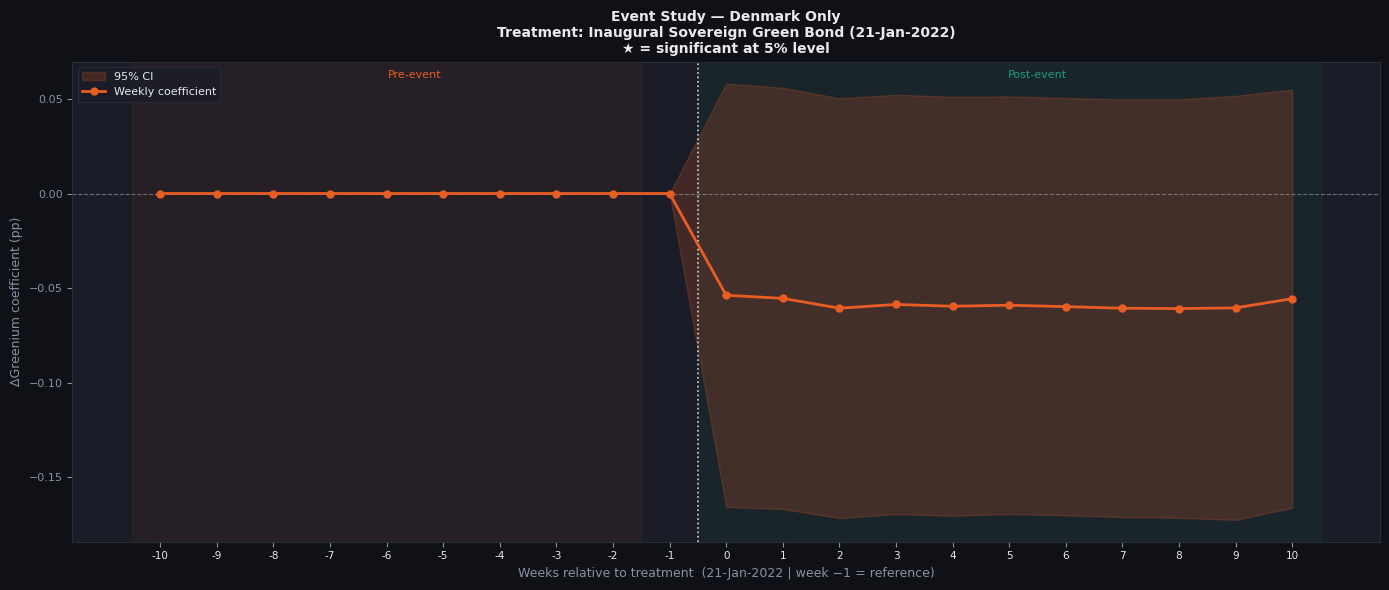

✓ Saved → d:\CEU_MA_EDP\Thesis_info\Thesis\output\regression_europe\event_study_denmark.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
style_ax(ax)

x_k  = np.array(all_weeks_dnk)
c_k  = np.array(coefs_dnk)
lo_k = np.array(lo_dnk)
hi_k = np.array(hi_dnk)

ax.axvspan(x_k.min() - 0.5, -1.5, alpha=0.06, color=ORANGE)
ax.axvspan(-0.5, x_k.max() + 0.5, alpha=0.06, color=TEAL)
ax.fill_between(x_k, lo_k, hi_k, alpha=0.2, color=ORANGE, label='95% CI')
ax.plot(x_k, c_k, color=ORANGE, linewidth=2.0, marker='o',
        markersize=5, label='Weekly coefficient', zorder=3)

for w, c, p in zip(all_weeks_dnk, coefs_dnk, p_dnk):
    if p < 0.05 and w != -1:
        ax.plot(w, c, marker='*', color=WHITE, markersize=12, zorder=4)

ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(-0.5, color=WHITE, linewidth=1.2, linestyle=':', alpha=0.9)

ax.set_xlabel('Weeks relative to treatment  (21-Jan-2022 | week −1 = reference)', fontsize=9)
ax.set_ylabel('ΔGreenium coefficient (pp)', fontsize=9)
ax.set_title(
    'Event Study — Denmark Only\n'
    'Treatment: Inaugural Sovereign Green Bond (21-Jan-2022)\n'
    '★ = significant at 5% level',
    fontsize=10, fontweight='bold', color=WHITE
)
ax.set_xticks(x_k)
ax.set_xticklabels([str(w) for w in all_weeks_dnk], fontsize=7.5, color=WHITE)
ax.text(-5.5, ax.get_ylim()[1] * 0.88, 'Pre-event', fontsize=8, color=ORANGE, ha='center')
ax.text(5.5,  ax.get_ylim()[1] * 0.88, 'Post-event', fontsize=8, color=TEAL, ha='center')
ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'event_study_denmark.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


---
# Part 6 — Side-by-Side Comparison Chart

Plots Germany and Denmark event study coefficients on the same axes for direct comparison.  
This is the key chart for the European robustness section of the thesis.

A consistent pattern of flat pre-event coefficients across both countries strengthens the parallel trends argument for the European DiD.


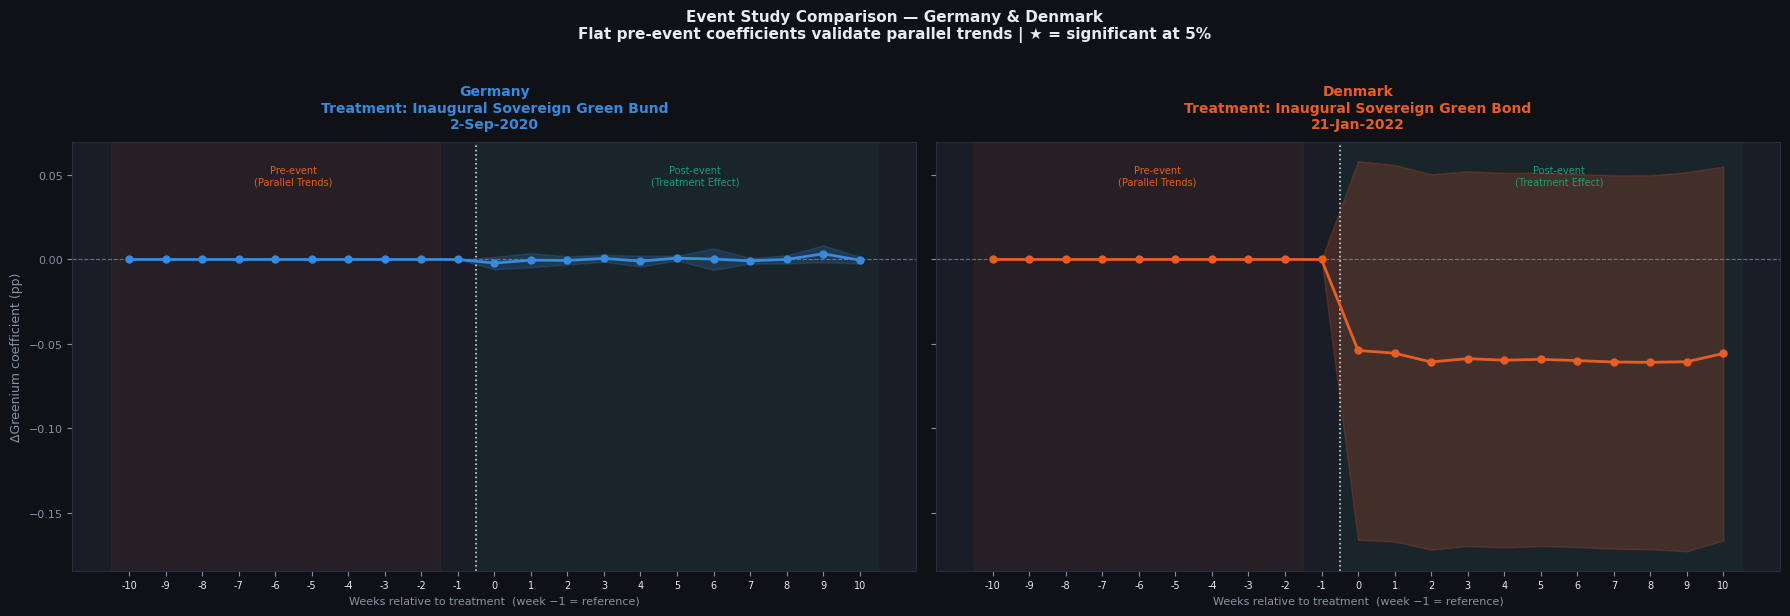

✓ Saved → d:\CEU_MA_EDP\Thesis_info\Thesis\output\regression_europe\event_study_comparison_europe.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)

titles = [
    ('Germany', BLUE,   all_weeks_deu, coefs_deu, lo_deu, hi_deu, p_deu,
     'Treatment: Inaugural Sovereign Green Bund\n2-Sep-2020'),
    ('Denmark', ORANGE, all_weeks_dnk, coefs_dnk, lo_dnk, hi_dnk, p_dnk,
     'Treatment: Inaugural Sovereign Green Bond\n21-Jan-2022'),
]

for ax, (country, color, weeks, coefs_, lo_, hi_, p_, subtitle) in zip(axes, titles):
    style_ax(ax)
    x_ = np.array(weeks)
    c_ = np.array(coefs_)
    l_ = np.array(lo_)
    h_ = np.array(hi_)

    ax.axvspan(x_.min() - 0.5, -1.5, alpha=0.06, color=ORANGE)
    ax.axvspan(-0.5, x_.max() + 0.5, alpha=0.06, color=TEAL)
    ax.fill_between(x_, l_, h_, alpha=0.2, color=color)
    ax.plot(x_, c_, color=color, linewidth=2.0, marker='o', markersize=5, zorder=3)

    for w, c, p in zip(weeks, coefs_, p_):
        if p < 0.05 and w != -1:
            ax.plot(w, c, marker='*', color=WHITE, markersize=14, zorder=4)

    ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
    ax.axvline(-0.5, color=WHITE, linewidth=1.2, linestyle=':', alpha=0.9)
    ax.set_xticks(x_)
    ax.set_xticklabels([str(w) for w in weeks], fontsize=7, color=WHITE)
    ax.set_xlabel('Weeks relative to treatment  (week −1 = reference)', fontsize=8)
    ax.set_title(f'{country}\n{subtitle}',
                 fontsize=10, fontweight='bold', color=color, pad=10)
    ax.text(-5.5, 0.9, 'Pre-event\n(Parallel Trends)',
            fontsize=7, color=ORANGE, ha='center', transform=ax.get_xaxis_transform())
    ax.text(5.5, 0.9, 'Post-event\n(Treatment Effect)',
            fontsize=7, color=TEAL, ha='center', transform=ax.get_xaxis_transform())

axes[0].set_ylabel('ΔGreenium coefficient (pp)', fontsize=9)
fig.suptitle(
    'Event Study Comparison — Germany & Denmark\n'
    'Flat pre-event coefficients validate parallel trends | ★ = significant at 5%',
    fontsize=11, fontweight='bold', color=WHITE, y=1.02
)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'event_study_comparison_europe.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show(); print(f"✓ Saved → {out}")


---
# Part 7 — Summary of Event Study Findings

Run this cell after all regressions to get a concise summary.

**What to report in the thesis:**
- If pre-event coefficients are flat and insignificant → parallel trends validated → DiD is credible
- If post-event coefficients are significant and negative → inaugural issuance compresses the greenium (H3 supported for Europe)
- Compare these patterns to the Asia event study to support the market maturity interpretation


In [18]:
print("=" * 65)
print("EVENT STUDY SUMMARY — EUROPE")
print("=" * 65)

for label, weeks, coefs_, p_ in [
    ("POOLED (Germany + Denmark)", all_weeks,     coefs,     pvals),
    ("GERMANY",                    all_weeks_deu, coefs_deu, p_deu),
    ("DENMARK",                    all_weeks_dnk, coefs_dnk, p_dnk),
]:
    pre_coefs  = [c for w, c in zip(weeks, coefs_) if w < -1]
    post_coefs = [c for w, c in zip(weeks, coefs_) if w > 0]
    pre_sig    = sum(1 for w, p in zip(weeks, p_) if w < -1 and p < 0.1)
    post_sig   = sum(1 for w, p in zip(weeks, p_) if w > 0  and p < 0.1)

    print(f"\n[{label}]")
    print(f"  Pre-event weeks:  mean coef = {np.mean(pre_coefs):+.5f} pp  "
          f"| significant weeks = {pre_sig}/{len(pre_coefs)}")
    print(f"  Post-event weeks: mean coef = {np.mean(post_coefs):+.5f} pp  "
          f"| significant weeks = {post_sig}/{len(post_coefs)}")
    pt = "✓ SUPPORTED (no pre-trend)" if pre_sig == 0 else "✗ VIOLATED — pre-trend detected"
    te = "✓ DETECTED" if post_sig > 0 else "✗ NOT DETECTED"
    print(f"  Parallel trends : {pt}")
    print(f"  Treatment effect: {te}")

print("\n" + "=" * 65)
print("Output files saved to:", OUTPUT_FOLDER)
print("  ├── event_study_pooled_europe.png")
print("  ├── event_study_germany.png")
print("  ├── event_study_denmark.png")
print("  └── event_study_comparison_europe.png")
print("\nCompare these results with Asia event study:")
print("  Asia:   output/regression/event_study_comparison.png")
print("  Europe: output/regression_europe/event_study_comparison_europe.png")


EVENT STUDY SUMMARY — EUROPE

[POOLED (Germany + Denmark)]
  Pre-event weeks:  mean coef = +0.00000 pp  | significant weeks = 0/9
  Post-event weeks: mean coef = -0.05875 pp  | significant weeks = 0/10
  Parallel trends : ✓ SUPPORTED (no pre-trend)
  Treatment effect: ✗ NOT DETECTED

[GERMANY]
  Pre-event weeks:  mean coef = +0.00000 pp  | significant weeks = 0/9
  Post-event weeks: mean coef = +0.00019 pp  | significant weeks = 0/10
  Parallel trends : ✓ SUPPORTED (no pre-trend)
  Treatment effect: ✗ NOT DETECTED

[DENMARK]
  Pre-event weeks:  mean coef = +0.00000 pp  | significant weeks = 0/9
  Post-event weeks: mean coef = -0.05910 pp  | significant weeks = 0/10
  Parallel trends : ✓ SUPPORTED (no pre-trend)
  Treatment effect: ✗ NOT DETECTED

Output files saved to: d:\CEU_MA_EDP\Thesis_info\Thesis\output\regression_europe
  ├── event_study_pooled_europe.png
  ├── event_study_germany.png
  ├── event_study_denmark.png
  └── event_study_comparison_europe.png

Compare these results wit